In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

spark = SparkSession.builder \
    .appName("ContainersDataAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "16") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

print("¡Sesión de PySpark iniciada exitosamente!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/03 10:26:12 WARN Utils: Your hostname, SCI-ISAAC-PRO.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.92 instead (on interface en0)
26/05/03 10:26:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/03 10:26:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


¡Sesión de PySpark iniciada exitosamente!


In [2]:

# Carpeta notebook
file_path = "./Containers_Dataset.csv"

# Leemos con inferSchema para que Spark detecte automáticamente tipos de datos
df = spark.read.csv(file_path, header=True, inferSchema=True)

print("Archivo cargado correctamente.")

Archivo cargado correctamente.


In [3]:
# Dimensiones básicas
print(f"\nESTADÍSTICAS GENERALES:")
print(f"Total de registros: {df.count()}")
print(f"Total de columnas: {len(df.columns)}")

# Tipos de datos
print("\nTIPOS DE DATOS POR COLUMNA:")
df.printSchema()

# identificación de valores faltantes (Solución al error de Timestamp)
print("\nCONTEO DE VALORES FALTANTES POR COLUMNA:")

# Definimos una función interna para manejar el tipo de dato
def count_missings(col_name, data_type):
    # Si es Double o Float, verificamos NaN y Null
    if data_type in ["double", "float"]:
        return count(when(isnan(col_name) | col(col_name).isNull(), col_name)).alias(col_name)
    # Para cualquier otro tipo (Timestamp, String, Int), solo verificamos Null
    else:
        return count(when(col(col_name).isNull(), col_name)).alias(col_name)

# Aplicamos la lógica recorriendo el esquema del DataFrame
df_faltantes = df.select([count_missings(c.name, c.dataType.simpleString()) for c in df.schema])

df_faltantes.show()

# Resumen estadístico
print("\nRESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS:")
df.describe().show()


ESTADÍSTICAS GENERALES:


Total de registros: 3231475
Total de columnas: 87

TIPOS DE DATOS POR COLUMNA:
root
 |-- Flow ID: string (nullable = true)
 |-- Src IP: string (nullable = true)
 |-- Src Port: integer (nullable = true)
 |-- Dst IP: string (nullable = true)
 |-- Dst Port: integer (nullable = true)
 |-- Protocol: integer (nullable = true)
 |-- Timestamp: timestamp (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packet: integer (nullable = true)
 |-- Total Bwd packets: integer (nullable = true)
 |-- Total Length of Fwd Packet: double (nullable = true)
 |-- Total Length of Bwd Packet: double (nullable = true)
 |-- Fwd Packet Length Max: double (nullable = true)
 |-- Fwd Packet Length Min: double (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: double (nullable = true)
 |-- Bwd Packet Length Min: double (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)


26/05/03 10:26:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------+--------+------+--------+--------+---------+-------------+----------------+-----------------+--------------------------+--------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+------------+-------------+------------+-----------+-----------+-----------+-------------+------------+-----------+-----------+-----------+-------------+-------------+-------------+-------------+-------------+-------------+-----------------+-----------------+-------------+-------------+-----------------+-----------------+------------------+-----------------+----------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+-------------------+--------------------+--------------------+------------

26/05/03 10:27:09 WARN DAGScheduler: Broadcasting large task binary with size 1084.2 KiB


+-------+--------------------+-----------+------------------+--------------+-----------------+------------------+--------------------+------------------+------------------+--------------------------+--------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+------------+--------------------+-------------+------------+------------+------------+--------------------+------------------+-------------------+------------------+------------------+--------------------+------------------+-------------------+-----------------+------------------+-----------------+-----------------+-------------+-------------+-------------------+--------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+----------------------+------------------+-----------------

In [4]:
# Analizamos la columna de etiquetas para ver qué tipos de ataques o eventos contiene

if "Label" in df.columns:
    print("DISTRIBUCIÓN DE EVENTOS DETECTADOS:")
    df.groupBy("Label").count().orderBy(desc("count")).show()

# Vista previa de los datos para inspección manual
print("\nPRIMEROS 5 REGISTROS PARA ANÁLISIS DE RELEVANCIA:")
df.show(5)

DISTRIBUCIÓN DE EVENTOS DETECTADOS:


+-----+-------+
|Label|  count|
+-----+-------+
|    0|2953291|
|    2| 156614|
|    1| 111251|
|   11|   8722|
|    8|    824|
|    6|    193|
|    3|    168|
|    4|    163|
|    7|    131|
|   10|     48|
|    5|     36|
|    9|     34|
+-----+-------+


PRIMEROS 5 REGISTROS PARA ANÁLISIS DE RELEVANCIA:
+--------------------+----------+--------+---------------+--------+--------+--------------------+-------------+----------------+-----------------+--------------------------+--------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+-----------------+-------------------+------------------+------------------+------------+------------+-------------+------------------+------------------+-----------+-----------+-------------+------------------+------------------+-----------+-----------+-------------+-------------+-------------+-------------+----

/opt/anaconda3/envs/env_pyspark/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


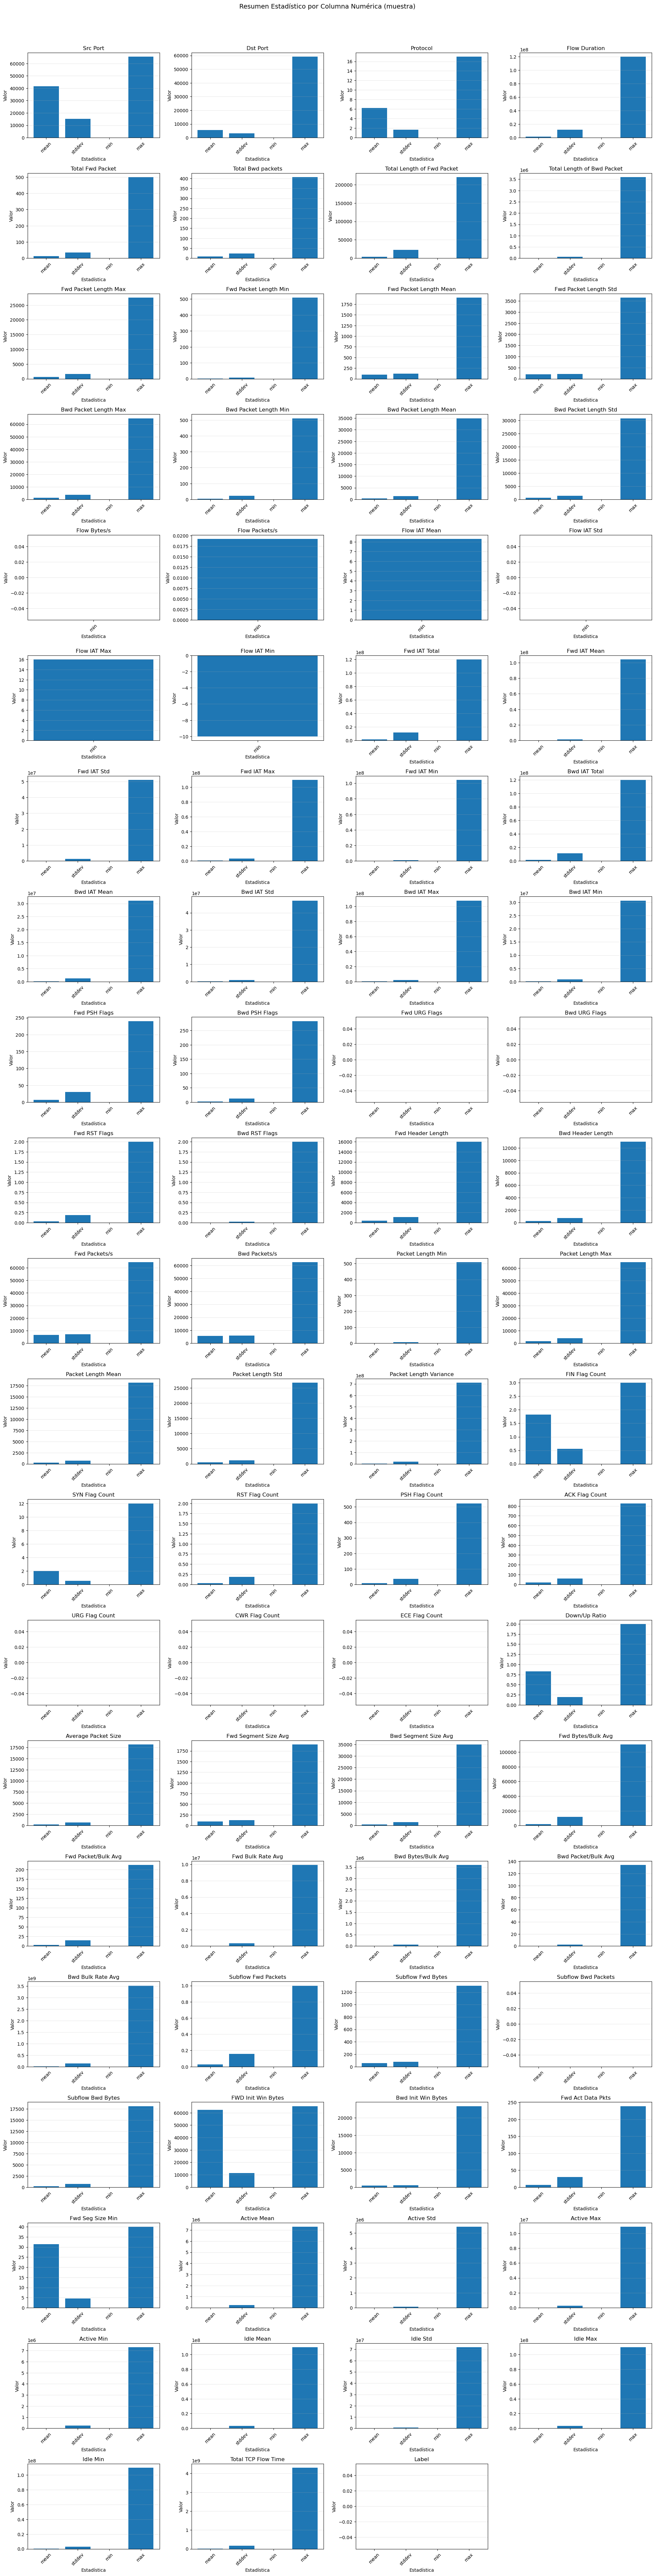

In [6]:
# Graficando estadísticas en una cuadrícula de 4 columnas
import math
import matplotlib.pyplot as plt
import pandas as pd

# Seleccionamos columnas numéricas
numeric_cols = [
    c.name for c in df.schema
    if c.dataType.simpleString() in ["double", "float", "int", "bigint", "long", "short"]
]

# Reducimos tamaño para análisis visual
sample_size = 100000
df_num = df.select(*numeric_cols).limit(sample_size) if numeric_cols else None

if numeric_cols and df_num is not None:
    # Resumen estadístico sobre muestra
    summary_df = df_num.describe().toPandas()
    metric_rows = summary_df[summary_df["summary"].isin(["mean", "stddev", "min", "max"])].copy()

    # Solo columnas presentes en el resumen
    plot_cols = [c for c in numeric_cols if c in metric_rows.columns]

    if plot_cols:
        ncols = 4
        nrows = math.ceil(len(plot_cols) / ncols)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.8 * nrows))

        # Unificamos formato para iterar aunque haya una sola fila
        if nrows == 1 and ncols == 1:
            axes = [axes]
        elif nrows == 1 or ncols == 1:
            axes = list(axes)
        else:
            axes = axes.flatten()

        for i, col_name in enumerate(plot_cols):
            ax = axes[i]
            values = pd.to_numeric(metric_rows[col_name], errors="coerce")
            labels = metric_rows["summary"]

            ax.bar(labels, values)
            ax.set_title(f"{col_name}")
            ax.set_xlabel("Estadística")
            ax.set_ylabel("Valor")
            ax.grid(axis="y", alpha=0.3)
            ax.tick_params(axis="x", rotation=45)

        # Ocultamos subplots vacíos
        for j in range(len(plot_cols), len(axes)):
            axes[j].set_visible(False)

        fig.suptitle("Resumen Estadístico por Columna Numérica (muestra)", fontsize=14)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()
    else:
        print("No hay columnas numéricas graficables en el resumen.")
else:
    print("No se detectaron columnas numéricas para graficar.")

In [12]:
# Estadísticas no numéricas en layout 3x3 con tablas
import pandas as pd
from IPython.display import HTML, display

non_numeric_cols = [
    c.name for c in df.schema
    if c.dataType.simpleString() not in ["double", "float", "int", "bigint", "long", "short"]
]

print("\nESTADÍSTICAS DE VARIABLES NO NUMÉRICAS:")

if non_numeric_cols:
    cards_html = []

    for col_name in non_numeric_cols:
        top_values = (
            df.groupBy(col_name)
              .count()
              .orderBy(desc("count"))
              .limit(10)
              .toPandas()
        )

        top_values[col_name] = top_values[col_name].fillna("(null)").astype(str)
        top_values.columns = [col_name, "Frecuencia"]

        table_html = top_values.to_html(index=False, classes="stats-table", border=0)

        cards_html.append(f"""
        <div class="stats-card">
            <h3>{col_name}</h3>
            {table_html}
        </div>
        """)

    grid_html = f"""
    <style>
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(3, minmax(0, 1fr));
            gap: 16px;
            align-items: start;
            margin-top: 12px;
        }}

        .stats-card {{
            background: #ffffff;
            border: 1px solid #d0d7de;
            border-radius: 10px;
            padding: 12px;
            box-shadow: 0 1px 3px rgba(0, 0, 0, 0.08);
            overflow-x: auto;
        }}

        .stats-card h3 {{
            margin: 0 0 10px 0;
            font-size: 16px;
            color: #0f172a;
        }}

        .stats-table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 12px;
        }}

        .stats-table th, .stats-table td {{
            border: 1px solid #e5e7eb;
            padding: 6px 8px;
            text-align: left;
            word-break: break-word;
        }}

        .stats-table th {{
            background: #f8fafc;
        }}

        @media (max-width: 1100px) {{
            .stats-grid {{
                grid-template-columns: repeat(2, minmax(0, 1fr));
            }}
        }}

        @media (max-width: 700px) {{
            .stats-grid {{
                grid-template-columns: 1fr;
            }}
        }}
    </style>

    <div class="stats-grid">
        {''.join(cards_html)}
    </div>
    """

    display(HTML(grid_html))
else:
    print("No se detectaron columnas no numéricas.")


ESTADÍSTICAS DE VARIABLES NO NUMÉRICAS:


Flow ID,Frecuencia
100.64.0.2-100.64.0.1-0-0-0,2605
10.16.0.6-114.114.114.114-0-0-0,2417
10.16.0.6-144.122.71.18-0-0-0,2346
10.16.0.6-144.122.71.18-53070-6443-6,809
144.122.71.18-10.16.0.4-6443-41270-6,762
144.122.71.18-10.16.0.5-6443-58358-6,760
10.16.0.7-144.122.71.18-47114-6443-6,713
10.16.0.6-144.122.71.18-48056-6443-6,282
10.16.0.6-144.122.71.18-49700-6443-6,258
8.6.0.1-8.0.6.4-0-0-0,255
